In [22]:
import struct
import numpy as np
from raw import epix
from matplotlib import pyplot as plt
E1_FMT = "<4sHHHHII"
E1_SZ  = struct.calcsize(E1_FMT)  # 20B
    

# paths mean the open shutter
dfile= '/data/L1/L1_20260327_102822.dat.160'
paths= []
for i in range(45):
    paths.append('/data/L1/L1_20260327_102822.dat.{}'.format(i+150))


In [23]:
def iter_l1bm_frames(path):
    with open(path, "rb") as f:
        while True:
            ssi = f.read(8)
            if not ssi: break
            if len(ssi) < 8: break

            orig32 = f.read(32)
            orig_u32=np.frombuffer(orig32, dtype='<u4', count=8)
            if len(orig32) < 32: break

            e1hdr = f.read(E1_SZ)                 
            if len(e1hdr) < E1_SZ: break
            magic, ny, nx, thr, _rsv, count, mbytes = struct.unpack(E1_FMT, e1hdr)
            if magic != b"E1BM": break

            _gap4 = f.read(4)                    
            if len(_gap4) < 4: break

            mask_bytes = f.read(mbytes)
            if len(mask_bytes) < mbytes: break

            vals_bytes = f.read(count * 2)
            if len(vals_bytes) < count * 2: break

            mask = np.unpackbits(np.frombuffer(mask_bytes, np.uint8), bitorder="big")
            mask = mask[:ny*nx].reshape(ny, nx).astype(bool)
            vals = np.frombuffer(vals_bytes, dtype="<u2", count=count)

            yield ssi, orig_u32, ny, nx, thr, mask, vals

# Example Readout 

In [24]:
def reconstruct(ny, nx, mask2d, vals, fill=0):
    img = np.full((ny, nx), fill, dtype=np.uint16)
    if vals.size:
        img[mask2d] = vals
    return img

In [25]:
def read_first(path):
    it = iter_l1bm_frames(path)
    try:
        ssi, orig32, ny, nx, thr, mask, vals = next(it)
    except StopIteration:
        print("Not A good Frame")
        return
    img = reconstruct(ny, nx, mask, vals, fill=0)
    #print(f"size={ny}x{nx}, thr={thr}, hits={vals.size} ({vals.size/(ny*nx):.1%})")
    return ssi, orig32, img     

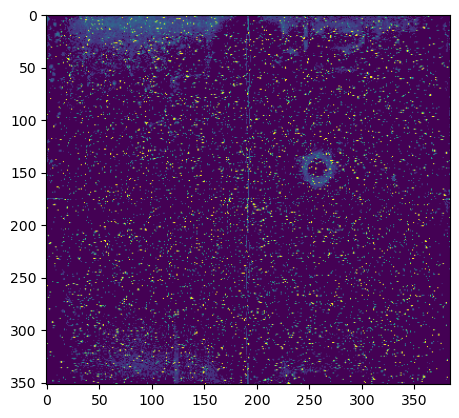

In [26]:
plt.imshow(epix.convert_image(read_first(dfile)[2]),vmin=0,vmax=500)

# Gain Calculation

In [6]:
from tqdm import tqdm
import numpy as np

def build_pixel_hist(paths, vmin=0, vmax=2200):
    nbins = vmax - vmin + 1
    hist_flat = None
    ny = nx = None
    n_frames = 0

    def all_frames():
        for path in paths:
            for frame in iter_l1bm_frames(path):
                yield path, frame

    for path, (ssi, orig32, ny_i, nx_i, thr_i, mask2d, vals) in tqdm(
        all_frames(), desc="frames"
    ):
        if hist_flat is None:
            ny, nx = ny_i, nx_i
            n_pix = ny * nx
            hist_flat = np.zeros((n_pix, nbins), dtype=np.uint32)
        else:
            if ny_i != ny or nx_i != nx:
                raise RuntimeError(
                    f"{path}: 帧尺寸不一致: got {ny_i}x{nx_i}, expected {ny}x{nx}"
                )

        n_frames += 1

        if vals.size == 0:
            continue  # 本帧没命中

        mask_flat = mask2d.ravel()
        hit_idx_all = np.nonzero(mask_flat)[0]  # 长度 == vals.size

        vals_i = vals.astype(np.int32, copy=False)
        valid = (vals_i >= vmin) & (vals_i <= vmax)
        if not np.any(valid):
            continue

        pix_idx = hit_idx_all[valid]
        bin_idx = vals_i[valid] - vmin  # 0..nbins-1

        np.add.at(hist_flat, (pix_idx, bin_idx), 1)

    if hist_flat is None:
        raise RuntimeError("所有文件都没有完整帧")

    if vmin == 0:
        # 非零 bin 是 1..nbins-1
        nonzero_counts = hist_flat[:, 1:].sum(axis=1)
        hist_flat[:, 0] = n_frames - nonzero_counts

    hist = hist_flat.reshape(ny, nx, nbins)
    return hist, ny, nx, n_frames



In [7]:
hist,ny,nx,n_frames=build_pixel_hist(paths[:10])

frames: 1618748it [55:07, 489.42it/s]


In [1]:
plt.plot(hist[125,100,100:],label="1st Quad")
plt.plot(hist[25,600,100:],label='3rd Quad')
plt.xlabel("ADC Value")
plt.ylabel("Counts")
plt.legend()
plt.show()

NameError: name 'plt' is not defined

In [ ]:
gain= (np.argmax(hist[:,:,100:],axis=2) + 100)/14.4
#np.save("new_gain.npy",gain)
#np.save("gain.npy",gain)
np.save("gain_{}".format(dfile.split("/")[-1]),gain)
plt.imshow(epix.convert_image(gain),vmin=5,vmax=20)
plt.colorbar()
print(np.median(gain))

# Energy Spectrum

In [36]:
import numpy as np
def centroid_filter(frame: np.ndarray, n2: float) -> np.ndarray:
    ny, nx = frame.shape
    as1 = frame * (frame > 4 * n2)

    up = np.zeros_like(as1)
    down = np.zeros_like(as1)
    left = np.zeros_like(as1)
    right = np.zeros_like(as1)

    up[0:ny - 1, :] = as1[1:, :]
    down[1:, :] = as1[0:ny - 1, :]
    left[:, 0:nx - 1] = as1[:, 1:nx]
    right[:, 1:nx] = as1[:, 0:nx - 1]

    cen_v = as1 + up + down + left + right
    cen_f = (as1 > up) & (as1 > down) & (as1 > left) & (as1 > right)

    return cen_v * cen_f

from tqdm import tqdm
import numpy as np

def build_energy_hist_charge(paths, bins, gain, selector, n2):
    gain = np.asarray(gain, dtype=np.float32)
    selector = np.asarray(selector, dtype=bool)

    if gain.shape != selector.shape:
        raise ValueError("gain 和 selector 形状必须一致")

    ny, nx = gain.shape
    gain_1d = gain.ravel()
    sel_1d  = selector.ravel()

    total_hist = np.zeros(len(bins) - 1, dtype=np.int64)

    def all_frames():
        for path in paths:
            for frame in iter_l1bm_frames(path):
                yield path, frame

    for path, (ssi, orig32, ny_i, nx_i, thr_i, mask2d, vals) in tqdm(all_frames(), desc="frames"):
        if ny_i != ny or nx_i != nx:
            raise RuntimeError(f"{path}: 帧尺寸不一致 got {ny_i}x{nx_i}, expected {ny}x{nx}")

        if vals.size == 0:
            continue

        frame2d = np.zeros((ny, nx), dtype=np.float32)
        frame2d[mask2d] = vals.astype(np.float32, copy=False)

        cs2d = centroid_filter(frame2d, n2=n2)

        cs_flat = cs2d.ravel()
        cent_idx_all = np.nonzero(cs_flat)[0]
        if cent_idx_all.size == 0:
            continue

        keep = sel_1d[cent_idx_all]
        if not np.any(keep):
            continue

        cent_idx = cent_idx_all[keep]
        cluster_charge = cs_flat[cent_idx]                 
        cent_gain = gain_1d[cent_idx]                      

        good = cent_gain > 0
        if not np.any(good):
            continue

        energy = cluster_charge[good] / cent_gain[good]    

        h, _ = np.histogram(energy, bins=bins)
        total_hist += h

    return total_hist

In [37]:
import numpy as np
from tqdm import tqdm

def build_energy_hist(paths, bins, gain, selector):

    gain = np.asarray(gain, dtype=np.float32)
    selector = np.asarray(selector, dtype=bool)

    if gain.shape != selector.shape:
        raise ValueError("gain 和 selector 形状必须一致")

    ny, nx = gain.shape
    gain_1d = gain.ravel()
    sel_1d  = selector.ravel()

    total_hist = np.zeros(len(bins)-1, dtype=np.int64)

    def all_frames():
        for path in paths:
            for frame in iter_l1bm_frames(path):
                yield path, frame

    for path, (ssi, orig32, ny_i, nx_i, thr_i, mask2d, vals) in tqdm(all_frames(), desc="frames"):
        if vals.size == 0:
            continue

        mask_1d = mask2d.ravel()
        hit_pixels_all = np.nonzero(mask_1d)[0]
        if hit_pixels_all.size == 0:
            continue

        
        keep = sel_1d[hit_pixels_all]
        if not np.any(keep):
            continue
        hit_pixels = hit_pixels_all[keep]
        hit_vals   = vals[keep].astype(np.float32)

        
        hit_gain = gain_1d[hit_pixels]
        good = hit_gain > 0
        if not np.any(good):
            continue

        energy = hit_vals[good] / hit_gain[good]

        frame_hist, _ = np.histogram(energy, bins=bins)
        total_hist += frame_hist

    return total_hist


In [38]:
import numpy as np
from tqdm import tqdm

def build_energy_hist_charge_sparse(paths, bins, gain, selector, n2):
    selector = np.asarray(selector, dtype=bool)
    gain = np.asarray(gain, dtype=np.float32)

    if selector.shape != gain.shape:
        raise ValueError(f"selector.shape {selector.shape} 和 gain.shape {gain.shape} mismatch")

    ny, nx = selector.shape
    N = ny * nx

    sel_flat = selector.ravel()
    gain_flat = gain.ravel()

    # 总直方图（bins 是 edges）
    total_hist = np.zeros(len(bins) - 1, dtype=np.int64)

    # lookup table：每帧只给 hit 像素赋值，其余为 0
    v_flat = np.zeros(N, dtype=np.float32)

    def all_frames():
        for path in paths:
            for frame in iter_l1bm_frames(path):
                yield path, frame

    for path, (ssi, orig32, ny_i, nx_i, thr_i, mask2d, vals) in tqdm(all_frames(), desc="frames"):
        if ny_i != ny or nx_i != nx:
            raise RuntimeError(f"{path}: Frame Shape incorrect: got {ny_i}x{nx_i}, expected {ny}x{nx}")

        if vals.size == 0:
            continue

        hit_idx_all = np.nonzero(mask2d.ravel())[0]
        if hit_idx_all.size == 0:
            continue

        if hit_idx_all.size != vals.size:
            raise RuntimeError(f"{path}: hit_idx_all.size={hit_idx_all.size} != vals.size={vals.size}")

        # 1) 填充 lookup
        v_flat.fill(0.0)
        v_flat[hit_idx_all] = vals.astype(np.float32, copy=False)

        i = hit_idx_all
        y = i // nx
        x = i - y * nx

        self_v = v_flat[i]

        # 2) 先做阈值（和你 _centroid_filter 一致：frame > 4*n2）
        thr = 4.0 * float(n2)
        keep_thr = self_v > thr
        if not np.any(keep_thr):
            continue

        i = i[keep_thr]
        y = y[keep_thr]
        x = x[keep_thr]
        self_v = self_v[keep_thr]

        # 3) 取邻居值：不用 clip，先判合法邻居再索引（更干净）
        up_ok    = y < (ny - 1)
        down_ok  = y > 0
        left_ok  = x < (nx - 1)
        right_ok = x > 0

        up_v    = np.zeros_like(self_v)
        down_v  = np.zeros_like(self_v)
        left_v  = np.zeros_like(self_v)
        right_v = np.zeros_like(self_v)

        up_v[up_ok]       = v_flat[i[up_ok] + nx]
        down_v[down_ok]   = v_flat[i[down_ok] - nx]
        left_v[left_ok]   = v_flat[i[left_ok] + 1]
        right_v[right_ok] = v_flat[i[right_ok] - 1]

        # 4) 局部极大中心判定（严格 >，与原函数一致）
        cen_f = (self_v > up_v) & (self_v > down_v) & (self_v > left_v) & (self_v > right_v)
        if not np.any(cen_f):
            continue

        cent_idx = i[cen_f]  # 中心像素线性索引
        cluster_charge = (self_v + up_v + down_v + left_v + right_v)[cen_f]

        # 5) selector 过滤中心像素
        sel_c = sel_flat[cent_idx]
        if not np.any(sel_c):
            continue

        cent_idx = cent_idx[sel_c]
        cluster_charge = cluster_charge[sel_c]

        # 6) gain>0
        g = gain_flat[cent_idx]
        good_g = g > 0
        if not np.any(good_g):
            continue

        energy = cluster_charge[good_g] / g[good_g]

        h, _ = np.histogram(energy, bins=bins)
        total_hist += h

    return total_hist


In [39]:
gain= np.load( "gain_{}.npy".format(dfile.split("/")[-1]) )

bins = np.linspace(0,200,3000)

filter1= np.load('/data/epix/software/Mossbauer/filter.npy')
filter2= (gain>8) * (gain<20 ) 
selector=  filter1* filter2 

In [75]:
file_n = 31
#hist_1= build_energy_hist_charge(paths[file_n:file_n+1], bins, gain, selector,n2=15)
hist_2= build_energy_hist(paths[file_n:file_n+1], bins, gain, selector)
hist_3= build_energy_hist_charge_sparse(paths[file_n:file_n+1], bins, gain, selector,n2=15)


frames: 161648it [01:08, 2376.48it/s]
frames: 161648it [02:04, 1301.82it/s]


In [43]:
file_n = 10 
hist_11= build_energy_hist_charge(paths2[file_n:file_n+1], bins, gain, selector,n2=15)
hist_21= build_energy_hist(paths2[file_n:file_n+1], bins, gain, selector)
hist_31= build_energy_hist_charge_sparse(paths2[file_n:file_n+1], bins, gain, selector,n2=15)

file_n = 0
hist_13= build_energy_hist_charge(paths3[file_n:file_n+1], bins, gain, selector,n2=15)
hist_23= build_energy_hist(paths3[file_n:file_n+1], bins, gain, selector)
hist_33= build_energy_hist_charge_sparse(paths3[file_n:file_n+1], bins, gain, selector,n2=15)

frames: 310341it [06:01, 859.04it/s]
frames: 310341it [00:37, 8290.20it/s]
frames: 310341it [01:02, 4926.61it/s]


np.float64(15.364083954782195)

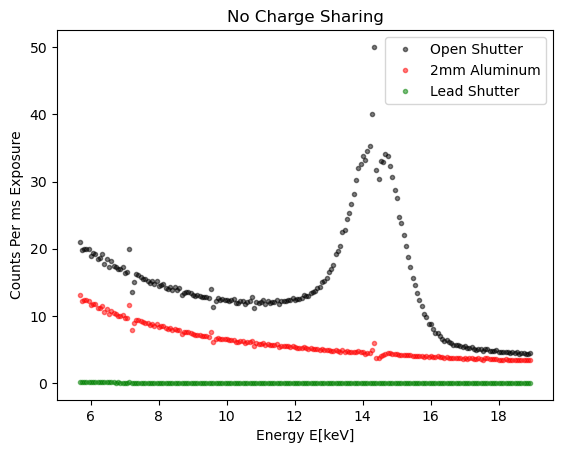

229.7744138920065
1.1553823052706538
1213.1274868147707
12.537512504168056
15.938646215405136


In [94]:
cstart=85
cend=285
ncenters= bins[cstart:cend]
nhist_12= hist_21[cstart:cend]/(200475*1.6)
nhist_22= hist_23[cstart:cend]/(310341*1.6)
nhist_32= hist_2[cstart:cend]/(161418*1.5)
#print(np.sum(nhist_12))
#print(np.sum(nhist_22))
#low_b = 0.10e7
#plt.axhline(low_b)
#plt.axhline(2*low_b,c= 'r')


start= 103
end=  154

plt.title("No Charge Sharing")
plt.plot(ncenters,nhist_32,'.',label='Open Shutter',c='k',alpha=0.5)
plt.plot(ncenters,nhist_12,'.',label='2mm Aluminum',c='r',alpha=0.5)
plt.plot(ncenters,nhist_22,'.',label='Lead Shutter',c='g',alpha=0.5)
#plt.plot(ncenters,nhist_1,'.',label='Charge Sharing',c='y',alpha=0.1)
#plt.plot(ncenters[start:end],nhist_1[start:end],'.',label='14keV',c='r')
plt.ylabel("Counts Per ms Exposure")
plt.xlabel("Energy E[keV]")
plt.legend()
plt.savefig("No_Charge_sharing_Small")
plt.show()

print(np.sum(nhist_12[start:end]))
print(np.sum(nhist_22[start:end]))
print(np.sum(nhist_32[start:end]))

print(ncenters[start])
print(ncenters[end])

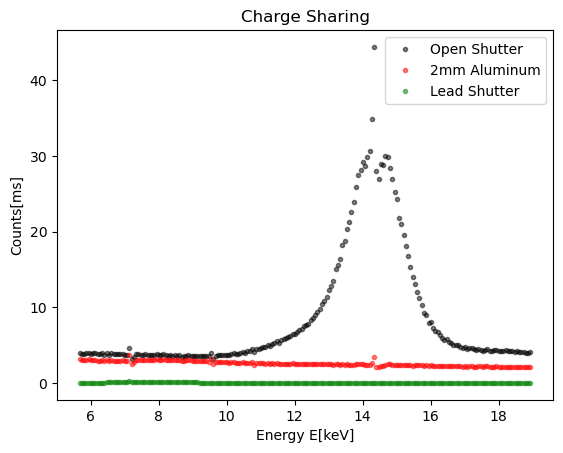

12.537512504168056
1028.7216667286177
123.72005549320365
0.5627297875562687
15.938646215405136


In [93]:
cstart=85
cend=285
ncenters= bins[cstart:cend]
nhist_12= hist_31[cstart:cend]/(200475*1.6)
nhist_22= hist_33[cstart:cend]/(310341*1.6)
nhist_32= hist_3[cstart:cend]/(161418*1.5)
#print(np.sum(nhist_12))
#print(np.sum(nhist_22))
#low_b = 0.10e7
#plt.axhline(low_b)
#plt.axhline(2*low_b,c= 'r')

start= 103
end=  154

plt.title("Charge Sharing")
plt.plot(ncenters,nhist_32,'.',label='Open Shutter',c='k',alpha=0.5)
plt.plot(ncenters,nhist_12,'.',label='2mm Aluminum',c='r',alpha=0.5)
plt.plot(ncenters,nhist_22,'.',label='Lead Shutter',c='g',alpha=0.5)
#plt.plot(ncenters,nhist_1,'.',label='Charge Sharing',c='y',alpha=0.1)
#plt.plot(ncenters[start:end],nhist_1[start:end],'.',label='14keV',c='r')
plt.ylabel("Counts[ms]")
plt.xlabel("Energy E[keV]")
plt.legend()
#plt.savefig("Compare_Charge_Sharing_Small")
plt.savefig("Charge_sharing_122_Small")
plt.show()

print(ncenters[start])
print(np.sum(nhist_32[start:end]))
print(np.sum(nhist_12[start:end]))
print(np.sum(nhist_22[start:end]))
print(ncenters[end])

In [ ]:
cstart=850
cend=2850

ncenters= bins[cstart:cend]
nhist_1= hist_1[cstart:cend]
nhist_2= hist_2[cstart:cend]
nhist_3= hist_3[cstart:cend]

low_b = 0.10e7
plt.axhline(low_b)
plt.axhline(2*low_b,c= 'r')

start= 103
end=  154

plt.plot(ncenters,nhist_3,'.',label='Fast Charge Sharing',c='k',alpha=0.5)
plt.plot(ncenters,nhist_2,'.',label='no Charge Sharing',c='g')
#plt.plot(ncenters,nhist_1,'.',label='Charge Sharing',c='y',alpha=0.1)
plt.plot(ncenters[start:end],nhist_1[start:end],'.',label='14keV',c='r')
plt.legend()
plt.show()

print(ncenters[start])
print(ncenters[end])

# Counts Array

In [12]:
#gain=np.load('new_gain.npy')
filter1= np.load('/data/epix/software/Mossbauer/filter.npy')
filter2= (gain>8) * (gain<20 ) 
selector=  filter1* filter2 
print(np.median(gain))

15.902777777777777


In [13]:
from tqdm import tqdm
import numpy as np

def count_value_over_gain_per_frame(paths, selector, gain, low=12.5, high=15.9):
    selector = np.asarray(selector, dtype=bool)
    gain = np.asarray(gain, dtype=np.float32)

    if selector.shape != gain.shape:
        raise ValueError(f"selector.shape {selector.shape} 和 gain.shape {gain.shape} 不一致")

    ny, nx = selector.shape
    sel_flat = selector.ravel()
    gain_flat = gain.ravel()

    counts = []

    def all_frames():
        for path in paths:
            for frame in iter_l1bm_frames(path):
                yield path, frame

    for path, (ssi, orig32, ny_i, nx_i, thr_i, mask2d, vals) in tqdm(
        all_frames(), desc="frames"
    ):
        if ny_i != ny or nx_i != nx:
            raise RuntimeError(
                f"{path}: 帧尺寸不一致: got {ny_i}x{nx_i}, expected {ny}x{nx}"
            )

        if vals.size == 0:
            counts.append(0)
            continue

        mask_flat = mask2d.ravel()
        hit_idx_all = np.nonzero(mask_flat)[0]
        if hit_idx_all.size == 0:
            counts.append(0)
            continue

        sel_hits_mask = sel_flat[hit_idx_all]         
        if not np.any(sel_hits_mask):
            counts.append(0)
            continue

        pix_idx  = hit_idx_all[sel_hits_mask]        
        vals_sel = vals[sel_hits_mask].astype(np.float32)
        gain_sel = gain_flat[pix_idx]

        valid_gain = gain_sel > 0
        if not np.any(valid_gain):
            counts.append(0)
            continue

        vals_sel = vals_sel[valid_gain]
        gain_sel = gain_sel[valid_gain]

        ratio = vals_sel / gain_sel

        n = np.count_nonzero((ratio >= low) & (ratio <= high))
        counts.append(int(n))

    return np.array(counts, dtype=np.int64)

In [14]:
from tqdm import tqdm
import numpy as np

def count_value_over_gain_per_frame_cs(paths, selector, gain, low=12.5, high=15.9, n2=15.0):
    selector = np.asarray(selector, dtype=bool)
    gain = np.asarray(gain, dtype=np.float32)

    if selector.shape != gain.shape:
        raise ValueError(f"selector.shape {selector.shape} 和 gain.shape {gain.shape} 不一致")

    ny, nx = selector.shape
    N = ny * nx
    sel_flat = selector.ravel()
    gain_flat = gain.ravel()

    counts = []

    v_flat = np.zeros(N, dtype=np.float32)

    thr = 4.0 * float(n2)  # 与你 _centroid_filter(frame, n2) 里一致：frame > 4*n2

    def all_frames():
        for path in paths:
            for frame in iter_l1bm_frames(path):
                yield path, frame

    for path, (ssi, orig32, ny_i, nx_i, thr_i, mask2d, vals) in tqdm(all_frames(), desc="frames"):
        if ny_i != ny or nx_i != nx:
            raise RuntimeError(f"{path}: 帧尺寸不一致: got {ny_i}x{nx_i}, expected {ny}x{nx}")

        if vals.size == 0:
            counts.append(0)
            continue

        hit_idx_all = np.nonzero(mask2d.ravel())[0]
        if hit_idx_all.size == 0:
            counts.append(0)
            continue

        if hit_idx_all.size != vals.size:
            raise RuntimeError(f"{path}: hit_idx_all.size={hit_idx_all.size} != vals.size={vals.size}")

        # 1) 填充查表（只填 hit 像素）
        v_flat.fill(0.0)
        v_flat[hit_idx_all] = vals.astype(np.float32, copy=False)

        i = hit_idx_all
        y = i // nx
        x = i - y * nx

        self_v = v_flat[i]

        # 2) 阈值（可选，但建议保留以匹配你之前的逻辑）
        keep_thr = self_v > thr
        if not np.any(keep_thr):
            counts.append(0)
            continue

        i = i[keep_thr]
        y = y[keep_thr]
        x = x[keep_thr]
        self_v = self_v[keep_thr]

        # 3) 邻居合法性（不 clip，避免越界“串值”）
        up_ok    = y < (ny - 1)
        down_ok  = y > 0
        left_ok  = x < (nx - 1)
        right_ok = x > 0

        up_v    = np.zeros_like(self_v)
        down_v  = np.zeros_like(self_v)
        left_v  = np.zeros_like(self_v)
        right_v = np.zeros_like(self_v)

        up_v[up_ok]       = v_flat[i[up_ok] + nx]
        down_v[down_ok]   = v_flat[i[down_ok] - nx]
        left_v[left_ok]   = v_flat[i[left_ok] + 1]
        right_v[right_ok] = v_flat[i[right_ok] - 1]

        # 4) 局部极大中心
        cen_f = (self_v > up_v) & (self_v > down_v) & (self_v > left_v) & (self_v > right_v)
        if not np.any(cen_f):
            counts.append(0)
            continue

        cent_idx = i[cen_f]
        cluster_charge = (self_v + up_v + down_v + left_v + right_v)[cen_f]

        # 5) selector 过滤中心像素
        keep_sel = sel_flat[cent_idx]
        if not np.any(keep_sel):
            counts.append(0)
            continue

        cent_idx = cent_idx[keep_sel]
        cluster_charge = cluster_charge[keep_sel]

        # 6) gain>0
        g = gain_flat[cent_idx]
        good_g = g > 0
        if not np.any(good_g):
            counts.append(0)
            continue

        ratio = cluster_charge[good_g] / g[good_g]

        # 7) 计数
        n = np.count_nonzero((ratio >= low) & (ratio <= high))
        counts.append(int(n))

    return np.array(counts, dtype=np.int64)


In [15]:
counts=count_value_over_gain_per_frame(paths,selector,gain)
counts2=count_value_over_gain_per_frame_cs(paths,selector,gain)

frames: 7272002it [38:01, 3187.73it/s]
frames: 7272002it [1:24:00, 1442.57it/s]


# Header and Time 

In [16]:
import numpy as np

def collect_orig_u32(paths):
    orig_list = []
    n_frames = 0

    for path in paths:
        for ssi, orig_u32, ny_i, nx_i, thr_i, mask2d, vals in iter_l1bm_frames(path):
            
            orig_list.append(np.array(orig_u32, copy=True))
            n_frames += 1

    orig_all = np.stack(orig_list, axis=0)  # (n_frames, 8)
    return orig_all

In [17]:
headers= collect_orig_u32(paths)

In [18]:
first_forward= 0
first_backward=  0

In [19]:
import mysql.connector
class sql_writer:
	def __init__(self,
				 host='192.168.2.2',
				 user='writer',
				 password='mossbauer_writer',
				 database='slowcontrol',
				 table='sc'):
		self.table = table  
		self.conn = mysql.connector.connect(
			host=host, user=user, password=password, database=database,
			autocommit=True, connection_timeout=5
		)
		self.cur = self.conn.cursor()
sql=sql_writer()

In [20]:
import numpy as np
import calendar
from datetime import datetime, UTC

def get_A_set_for_timestamps(sql, timestamps):
    ts = np.asarray(timestamps, dtype=np.int64)
    if ts.size == 0:
        return []

    order = np.argsort(ts)
    ts_sorted = ts[order]
    t_min = int(ts_sorted[0])
    t_max = int(ts_sorted[-1])

    fmt = "%Y-%m-%d %H:%M:%S"
    dt_start = datetime.fromtimestamp(t_min, UTC).replace(tzinfo=None)
    dt_end   = datetime.fromtimestamp(t_max, UTC).replace(tzinfo=None)
    start_str = dt_start.strftime(fmt)
    end_str   = dt_end.strftime(fmt)

    cmd = (
        "SELECT `TIME`, `A_set` FROM sc "
        "WHERE `TIME` BETWEEN '{start}' AND '{end}' "
        "ORDER BY `TIME`"
    ).format(start=start_str, end=end_str)

    sql.cur.execute(cmd)
    rows = sql.cur.fetchall()

    if not rows:
        return [None] * ts.size

    times_sc = np.array(
        [calendar.timegm(r[0].timetuple()) for r in rows],  # r[0] 是 TIME
        dtype=np.int64,
    )
    aset_sc = [r[1] for r in rows]  # r[1] 是 A_set

    A_sorted = [None] * ts_sorted.size
    j = 0
    cur = None
    m = len(times_sc)

    for i, t in enumerate(ts_sorted):
        while j < m and times_sc[j] <= t:
            cur = aset_sc[j]
            j += 1
        A_sorted[i] = cur  

    A_out = [None] * ts.size
    for idx_sorted, orig_idx in enumerate(order):
        A_out[orig_idx] = A_sorted[idx_sorted]

    return A_out


In [21]:
A_set=get_A_set_for_timestamps(sql,headers[:,7])

# Final Result

In [22]:
def group_mean_by_A(A, counts):
    A = np.asarray(A)
    counts = np.asarray(counts)

    uniq_A, inv = np.unique(A, return_inverse=True)
    sum_per_A = np.bincount(inv, weights=counts)
    cnt_per_A = np.bincount(inv)
    mean_per_A = sum_per_A / cnt_per_A
    return uniq_A, mean_per_A

In [23]:
# forward
offset=0
forward_counts = counts[first_forward+offset::1]
forward_A      = A_set[first_forward+offset::1]
uniq_A_fwd, mean_fwd = group_mean_by_A(forward_A, forward_counts)
# backward flip
uniq_A_bwd = uniq_A_fwd.copy()
mean_bwd= mean_fwd.copy()

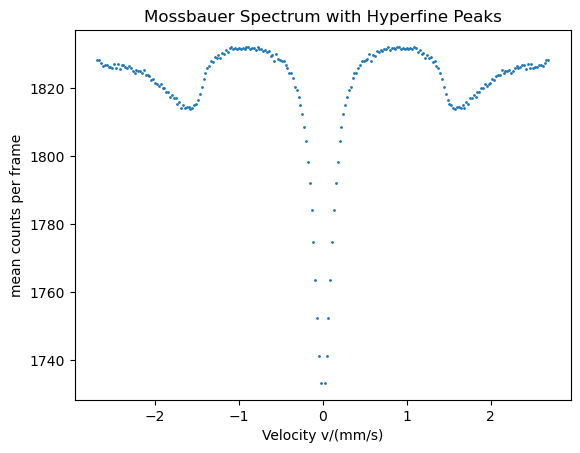

In [24]:
x_bwd = np.flip(uniq_A_bwd[1:])
y_bwd = np.flip(mean_bwd[1:])
x_fwd = uniq_A_fwd[1:]
y_fwd = mean_fwd[1:]
x_all = np.concatenate([-x_bwd, x_fwd])
y_all = np.concatenate([y_bwd, y_fwd])
v= np.array(x_all).astype(float) * (20e-6/170) * 200  * np.pi * 1000 
plt.scatter(v, y_all, marker="o",s=1)
plt.xlabel("Velocity v/(mm/s)")
plt.ylabel("mean counts per frame")
plt.title("Mossbauer Spectrum with Hyperfine Peaks")
plt.savefig("tidy_results/HUGE_SPECTRUM5_2")
#plt.savefig("big_spectrum_{}".format(offset))
plt.show()

In [25]:
# forward
offset=0
forward_counts = counts2[first_forward+offset::1]
forward_A      = A_set[first_forward+offset::1]
uniq_A_fwd, mean_fwd = group_mean_by_A(forward_A, forward_counts)
# backward flip
uniq_A_bwd = uniq_A_fwd.copy()
mean_bwd= mean_fwd.copy()

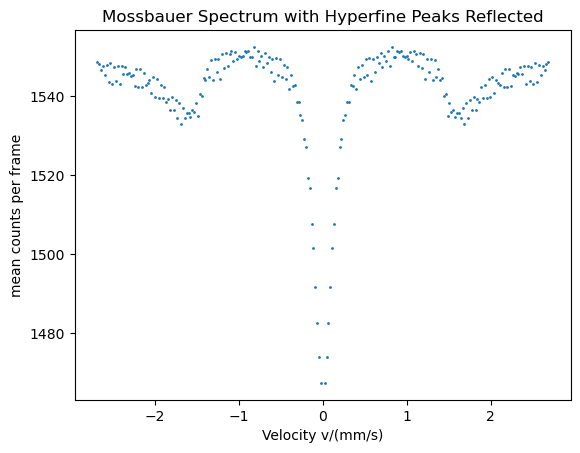

In [26]:
x_bwd = np.flip(uniq_A_bwd[1:])
y_bwd = np.flip(mean_bwd[1:])
x_fwd = uniq_A_fwd[1:]
y_fwd = mean_fwd[1:]
x_all = np.concatenate([-x_bwd, x_fwd])
y_all = np.concatenate([y_bwd, y_fwd])
v= np.array(x_all).astype(float) * (20e-6/170) * 200  * np.pi * 1000 
plt.scatter(v, y_all, marker="o",s=1)
plt.xlabel("Velocity v/(mm/s)")
plt.ylabel("mean counts per frame")
plt.title("Mossbauer Spectrum with Hyperfine Peaks Reflected")
plt.savefig("tidy_results/HUGE_SPECTRUM6_2")
#plt.savefig("big_spectrum_{}".format(offset))
plt.show()

In [27]:
%reset -f 

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit

# 1. Your Data
y_data = y_all # Paste your full array here
x_data = np.arange(len(y_data))

# 2. Lorentzian Model (as a dip)
def lorentzian(x, x0, fwhm, depth, baseline):
    return baseline - depth / (1 + ((x - x0) / (fwhm / 2))**2)

# 3. Define Windows and Guesses for each peak
# (start_index, end_index, [center_guess, fwhm_guess, depth_guess, baseline_guess])
peaks = [
    (0, 100,   [49, 30, 20, 1580]),  # Left Peak
    (100, 150, [126, 10, 90, 1580]), # Center Peak
    (150, 256, [202, 30, 20, 1580])  # Right Peak
]

# 4. Fit and Plot
plt.figure(figsize=(10, 5))
plt.scatter(x_all, y_data, s=5, color='black', alpha=0.3)

colors = ['blue', 'red', 'green']
for i, (start, end, guess) in enumerate(peaks):
    # Slice the data for the specific window
    x_slice = x_data[start:end]
    y_slice = y_data[start:end]
    
    # Perform the fit
    popt, _ = curve_fit(lorentzian, x_slice, y_slice, p0=guess)
    
    # Plot the result
    plt.plot(x_all[start:end], lorentzian(x_slice, *popt), color=colors[i], lw=2.5, alpha=0.5)
    
    print(f"Peak {i+1} | Center: {popt[0]:.2f}, FWHM: {popt[1]:.2f}, Depth: {popt[2]:.2f}")

plt.xlabel("Velocity v[mm/s]")
plt.ylabel("Counts")
plt.grid(True, alpha=0.3)

plt.savefig('fit')
plt.show()